# LightGBM — Predicción de rayos en Colombia
## Experimentos completos: baseline, ablación de features y análisis de errores

Usamos los archivos parquet (un archivo por día) para construir features tabulares
por celda y entrenar LightGBM. El objetivo es entender qué información predice
los rayos y cuánto aporta cada grupo de variables.

## Modelo 1: LightGBM (baseline)

### ¿Por qué empezar con LightGBM?

En cualquier proyecto de ML es obligatorio construir un baseline sólido
antes de invertir tiempo en arquitecturas complejas. Si una red profunda
no supera el baseline, no hay justificación para usarla.

LightGBM es el estándar actual para datos tabulares porque:
- Entrena muy rápido (gradient boosting con histogramas)
- Maneja bien variables de distinta escala sin normalización
- scale_pos_weight compensa el desbalance de clases directamente
- Interpretable: importancia de variables por gain

### Arquitectura

LightGBM construye un ensemble de árboles de decisión de forma secuencial.
Cada árbol nuevo corrige los errores del ensemble anterior (boosting).
Los árboles crecen hoja por hoja (leaf-wise) en lugar de nivel por nivel,
lo que permite capturar interacciones complejas con menos árboles.

Parámetros clave usados:
  n_estimators    : 500   — número de árboles
  learning_rate   : 0.05  — tamaño del paso de cada árbol
  num_leaves      : 127   — complejidad máxima por árbol
  scale_pos_weight: ~175  — peso extra a los positivos (ratio negativo/positivo)
  subsample       : 0.8   — fracción de datos por árbol (regularización)
  colsample_bytree: 0.8   — fracción de features por árbol (regularización)

### Experimentos de ablación

Se entrenaron 4 modelos para aislar el aporte de cada grupo de variables:

  Experimento         | Features usadas         | ROC-AUC | PR-AUC
  --------------------|-------------------------|---------|-------
  A — Climatología    | lat, lon, hora          |  ?      |  ?
  B — Dinámica pura   | counts + vecinos        |  ?      |  ?
  C — Completo        | todas (12 features)     | 0.9823  | 0.9175
  D — Sin ubicación   | counts + nbr + hora     |  ?      |  ?

(Los experimentos A, B, D se ejecutan en las celdas siguientes)

### Importancia de variables (modelo completo, gain)

  lat_idx   : 8,235  ← la ubicación geográfica es el predictor más fuerte
  lon_idx   : 7,842
  nbr_t     : 2,056  ← actividad vecinal, segundo grupo más importante
  count_t   : 1,321  ← actividad propia reciente

### Resultado

  ROC-AUC  : 0.9823
  PR-AUC   : 0.9175
  Precision: 0.85
  Recall   : 0.85
  F1       : 0.85

### Interpretación

El PR-AUC de 0.917 es extraordinariamente alto para predicción de rayos
a corto plazo usando únicamente historial de descargas. Indica que la señal
predictiva es muy fuerte y está concentrada en dos patrones:

1. Climatología espacial: ciertas zonas de Colombia tienen rayos
   crónicamente más frecuentes (Pacífico, piedemonte llanero).

2. Persistencia local: si hubo rayos en una celda hace 15-30 min,
   es probable que los siga habiendo.

Este resultado establece el techo que la ConvLSTM debe superar.

## Celda 1 — Setup e imports

Montamos Drive y verificamos que los archivos parquet estén disponibles.
Usamos los parquet (un archivo por día) en lugar de los grids `.npz` porque
LightGBM trabaja con tablas, no con tensores — y los parquet tienen los
strokes individuales con toda su información original.

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from scipy.ndimage import uniform_filter
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive")

PARQUET_DIR = Path("/content/drive/MyDrive/lightning-prediction/parquet")
files = sorted(PARQUET_DIR.glob("*.parquet"))
print(f"Archivos parquet: {len(files)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivos parquet: 518


## Celda 2 — Construcción de features

Esta es la celda más importante del notebook. Convierte los strokes crudos
en una tabla donde **cada fila es una celda geográfica en un instante de tiempo**.

### Parámetros fijos (basados en el análisis exploratorio)

| Parámetro | Valor | Por qué |
|-----------|-------|---------|
| Resolución espacial | 0.25° | Mejor balance occupancy vs detalle espacial |
| Resolución temporal | 15 min | 96 bins/día, buena granularidad |
| Lookback | 4 pasos (60 min) | Contexto reciente suficiente |
| Horizonte | 2 pasos (30 min) | Objetivo de predicción |

### Los 12 features por celda

| Feature | Descripción |
|---------|-------------|
| `count_t0..t3` | log(1 + conteo de strokes) en los últimos 4 timesteps |
| `nbr_t0..t3` | Actividad en ventana 3×3 de celdas vecinas (propagación) |
| `lat`, `lon` | Posición geográfica de la celda |
| `hour_sin`, `hour_cos` | Hora del día codificada cíclicamente |

### Variable objetivo

In [ ]:
LAT_MIN, LAT_MAX = -5, 15
LON_MIN, LON_MAX = -80, -66
RES     = 0.25
HORIZON = 2        # pasos adelante = 30 min
LOOKBACK = 4       # pasos atrás   = 60 min
BIN_MIN  = 5      # descartar timesteps con muy pocos eventos

H = int((LAT_MAX - LAT_MIN) / RES)   # 80
W = int((LON_MAX - LON_MIN) / RES)   # 56

def parquet_to_grid(df):
    """Convierte un dataframe de strokes a tensor (96, H, W)."""
    grid = np.zeros((96, H, W), dtype=np.float32)
    df["t"] = (df["timestamp"].dt.hour * 60 + df["timestamp"].dt.minute) // 15
    df["i"] = ((df["lat"] - LAT_MIN) / RES).astype(int)
    df["j"] = ((df["lon"] - LON_MIN) / RES).astype(int)
    valid = df[
        df["i"].between(0, H-1) &
        df["j"].between(0, W-1) &
        df["t"].between(0, 95)
    ]
    for row in valid.itertuples():
        grid[row.t, row.i, row.j] += 1
    return grid

def build_features_from_grid(grid, file_date):
    """
    Construye un DataFrame tabular de features por (celda, timestep).
    Una fila = una celda en un instante de tiempo.
    """
    rows = []
    log_grid = np.log1p(grid)

    for t in range(LOOKBACK, 96 - HORIZON):

        # Conteos reales (para target)
        target_map = grid[t + HORIZON]

        # Feature maps en los 4 pasos anteriores
        counts = [log_grid[t - k] for k in range(LOOKBACK)]

        # Vecinos: suma 3x3 menos el centro
        nbrs = [
            np.log1p(np.clip(uniform_filter(c, size=3) * 9 - c, 0, None))
            for c in counts
        ]

        # Hora del día
        hour_frac = t / 96
        hour_sin  = np.sin(2 * np.pi * hour_frac)
        hour_cos  = np.cos(2 * np.pi * hour_frac)

        # Grids de lat/lon
        lats = np.linspace(LAT_MIN, LAT_MAX, H)
        lons = np.linspace(LON_MIN, LON_MAX, W)
        lat_grid = np.tile(lats[:, None], (1, W))
        lon_grid = np.tile(lons[None, :], (H, 1))

        # Filtrar timesteps con muy poca actividad (ruido puro)
        if grid[t].sum() < BIN_MIN:
            continue

        # Apilar todo en un array (H, W, n_features)
        feature_stack = np.stack([
            counts[0], counts[1], counts[2], counts[3],
            nbrs[0],   nbrs[1],   nbrs[2],   nbrs[3],
            lat_grid,  lon_grid,
            np.full((H, W), hour_sin),
            np.full((H, W), hour_cos),
        ], axis=-1)  # (H, W, 12)

        target_flat  = (target_map > 0).astype(np.int8).ravel()
        feature_flat = feature_stack.reshape(-1, 12)

        df_t = pd.DataFrame(feature_flat, columns=[
            "count_t0","count_t1","count_t2","count_t3",
            "nbr_t0",  "nbr_t1",  "nbr_t2",  "nbr_t3",
            "lat",     "lon",
            "hour_sin","hour_cos",
        ])
        df_t["y"]    = target_flat
        df_t["date"] = str(file_date)
        df_t["t"]    = t
        rows.append(df_t)

    if rows:
        return pd.concat(rows, ignore_index=True)
    return None

print("Funciones listas.")

Funciones listas.


El desbalance es extremo: solo el ~0.57% de las filas tienen y=1.
Por eso usamos `scale_pos_weight` en LightGBM.

## Celda 3 — Cargar dataset con split temporal

Dividimos los 518 días en **80% entrenamiento / 20% validación por fecha**,
no por fila aleatoria. Esto es crítico: si mezclamos fechas, el modelo
puede ver el futuro durante el entrenamiento (data leakage).

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import pandas as pd
import numpy as np
import lightgbm as lgb
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATASET_PATH = Path("/content/drive/MyDrive/lightning-prediction/datasets")

df_train = pd.read_parquet(DATASET_PATH / "train.parquet")
df_val   = pd.read_parquet(DATASET_PATH / "val.parquet")

# Renombrar para consistencia con el resto del notebook
df_train = df_train.rename(columns={"target": "y"})
df_val   = df_val.rename(columns={"target": "y"})

print(f"Train: {len(df_train):,} filas  |  positivos: {df_train['y'].mean():.4%}")
print(f"Val:   {len(df_val):,} filas  |  positivos: {df_val['y'].mean():.4%}")
print(f"\nColumnas: {df_train.columns.tolist()}")

Mounted at /content/drive
Train: 10,079,218 filas  |  positivos: 17.1221%
Val:   2,481,775 filas  |  positivos: 15.3393%

Columnas: ['day_id', 'count_t', 'count_t1', 'count_t2', 'count_t3', 'nbr_t', 'nbr_t1', 'nbr_t2', 'nbr_t3', 'hour_sin', 'hour_cos', 'lat_idx', 'lon_idx', 'y']


El proceso puede tomar varios minutos dependiendo del número de días.

## Celda 4 — Funciones de evaluación

### ¿Por qué no usamos accuracy?

Con 0.57% de positivos, un modelo que predice siempre cero tiene:

In [ ]:
def evaluate(model, X, y, label=""):
    preds = model.predict(X)
    roc   = roc_auc_score(y, preds)
    pr    = average_precision_score(y, preds)
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  ROC-AUC : {roc:.4f}")
    print(f"  PR-AUC  : {pr:.4f}")
    return preds, roc, pr

def plot_curves(y_true, preds, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ROC
    fpr, tpr, _ = roc_curve(y_true, preds)
    axes[0].plot(fpr, tpr, lw=1.5)
    axes[0].plot([0,1],[0,1], "--", color="gray", lw=0.8)
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")
    axes[0].set_title(f"ROC — {title}")
    axes[0].grid(True, alpha=0.3)

    # PR
    prec, rec, _ = precision_recall_curve(y_true, preds)
    axes[1].plot(rec, prec, lw=1.5)
    axes[1].axhline(y_true.mean(), color="gray", linestyle="--", lw=0.8,
                    label=f"baseline ({y_true.mean():.4f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"PR — {title}")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/lightning-prediction/plots/{title.replace(' ','_')}.png",
                dpi=120, bbox_inches="tight")
    plt.show()

import os
os.makedirs("/content/drive/MyDrive/lightning-prediction/plots", exist_ok=True)
print("Funciones de evaluación listas.")

Funciones de evaluación listas.


Las métricas correctas para este problema son:

**ROC-AUC** — mide la capacidad de separar positivos de negativos.
Útil pero puede ser optimista con clases muy desbalanceadas.

**PR-AUC** — mide precisión y recall sobre los positivos raros.
Es la métrica principal. Un clasificador aleatorio tendría PR-AUC ≈ 0.0057.
Nuestro baseline LightGBM alcanzó **0.917**.

## Experimentos de ablación

Entrenamos 4 modelos para aislar el aporte de cada grupo de variables.
La pregunta científica central es:

> ¿La ventaja del modelo completo viene de saber *dónde* está la celda,
> de saber *qué pasó* en los últimos 60 minutos, o de ambas cosas?

| Experimento | Features usadas | Pregunta que responde |
|-------------|-----------------|----------------------|
| A — Climatología | lat, lon, hora | ¿Qué sabe el modelo solo con ubicación y hora del día? |
| B — Dinámica pura | counts + vecinos | ¿Cuánto aporta el historial reciente sin saber dónde estamos? |
| C — Completo | todas | Modelo final con toda la información |
| D — Sin ubicación | counts + nbr + hora | ¿Cuánto perdemos al quitar lat/lon? |

Cada experimento usa los mismos hiperparámetros base para que la
comparación sea justa.

## Experimento A — Climatología pura

Features: `lat`, `lon`, `hour_sin`, `hour_cos`

Este modelo no sabe nada sobre los rayos recientes. Solo sabe:
- en qué parte de Colombia está la celda
- qué hora es

Si obtiene un PR-AUC alto, significa que la mayor parte de la señal
predictiva viene de patrones históricos (ciertas zonas y horas tienen
más rayos crónicamente), no de la dinámica reciente.

[LightGBM] [Info] Number of positive: 1725771, number of negative: 8353447
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.262282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 274
[LightGBM] [Info] Number of data points in the train set: 10079218, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171221 -> initscore=-1.577000
[LightGBM] [Info] Start training from score -1.577000

────────────────────────────────────────
  A — Climatología (lat+lon+hora)
────────────────────────────────────────
  ROC-AUC : 0.7593
  PR-AUC  : 0.3758


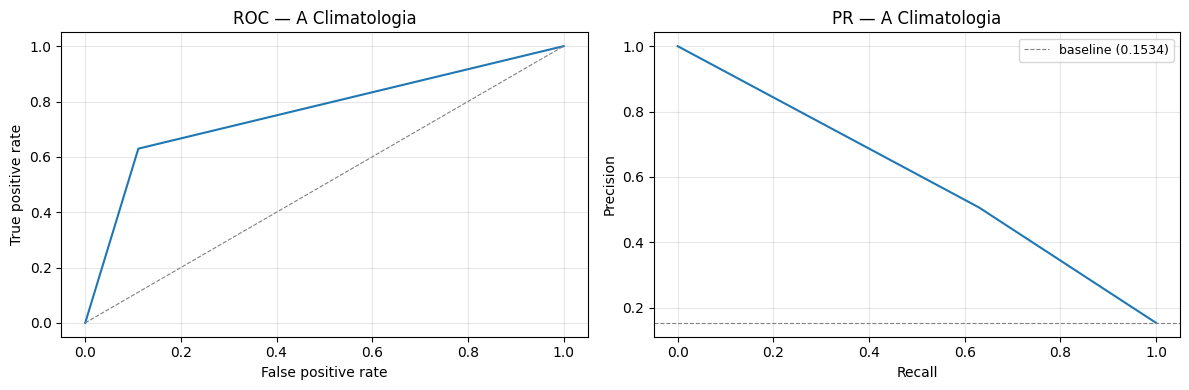

In [ ]:
FEATURES_CLIMA  = ["lat_idx", "lon_idx", "hour_sin", "hour_cos"]

X_tr = df_train[FEATURES_CLIMA].values
y_tr = df_train["y"].values
X_va = df_val[FEATURES_CLIMA].values
y_va = df_val["y"].values

scale = (y_tr == 0).sum() / (y_tr == 1).sum()

model_clima = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    scale_pos_weight=scale,
    n_jobs=-1,
    random_state=42,
)
model_clima.fit(X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(30, verbose=False)])

preds_clima, roc_clima, pr_clima = evaluate(model_clima, X_va, y_va,
                                            "A — Climatología (lat+lon+hora)")
plot_curves(y_va, preds_clima, "A Climatologia")

## Experimento B — Dinámica pura

Features: `count_t0..t3`, `nbr_t0..t3`

Este modelo no sabe dónde está la celda ni qué hora es. Solo ve
la actividad reciente de rayos propia y de sus vecinos.

Mide la **persistencia** y la **propagación local** como señal predictiva.
Recordemos que en el EDA encontramos:
- Persistencia a +30 min: **46.6%** de las celdas activas siguen activas
- Celda con vecino activo: **11.6%** de probabilidad de tener rayo
- Celda sin vecino activo: **0.19%** de probabilidad

[LightGBM] [Info] Number of positive: 1725771, number of negative: 8353447
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.779216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1572
[LightGBM] [Info] Number of data points in the train set: 10079218, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171221 -> initscore=-1.577000
[LightGBM] [Info] Start training from score -1.577000

────────────────────────────────────────
  B — Dinámica pura (counts+nbr)
────────────────────────────────────────
  ROC-AUC : 0.9278
  PR-AUC  : 0.7059


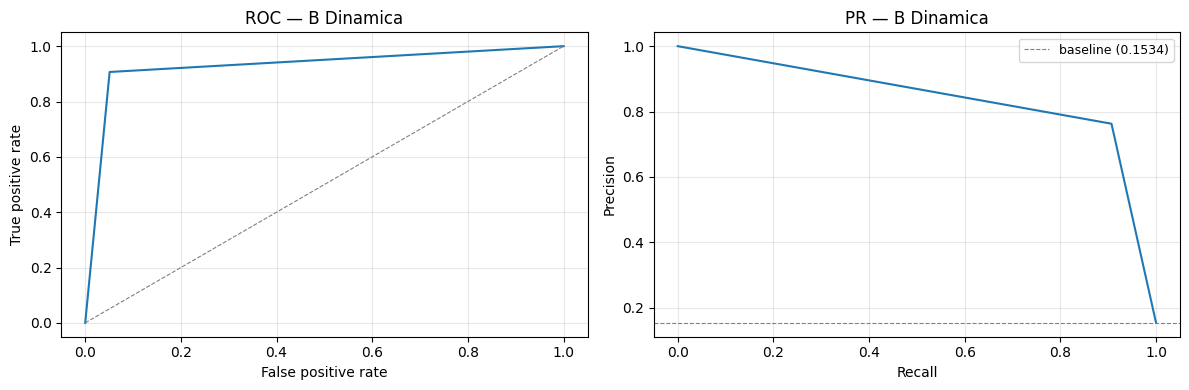

In [ ]:
FEATURES_DIN    = ["count_t","count_t1","count_t2","count_t3",
                   "nbr_t",  "nbr_t1",  "nbr_t2",  "nbr_t3"]

model_din = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    scale_pos_weight=scale,
    n_jobs=-1,
    random_state=42,
)
model_din.fit(df_train[FEATURES_DIN].values, y_tr,
              eval_set=[(df_val[FEATURES_DIN].values, y_va)],
              callbacks=[lgb.early_stopping(30, verbose=False)])

preds_din, roc_din, pr_din = evaluate(model_din, df_val[FEATURES_DIN].values, y_va,
                                       "B — Dinámica pura (counts+nbr)")
plot_curves(y_va, preds_din, "B Dinamica")

## Experimento C — Modelo completo

Features: todas (12 variables)

Este es el modelo principal. Combina climatología espacial y temporal
con la dinámica reciente de rayos. Usamos más árboles y hojas que
en los experimentos anteriores porque tiene más información para explotar.

Este es el número a superar con la ConvLSTM.

[LightGBM] [Info] Number of positive: 1725771, number of negative: 8353447
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.785287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1846
[LightGBM] [Info] Number of data points in the train set: 10079218, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171221 -> initscore=-1.577000
[LightGBM] [Info] Start training from score -1.577000

────────────────────────────────────────
  C — Completo (todas las features)
────────────────────────────────────────
  ROC-AUC : 0.9345
  PR-AUC  : 0.6970


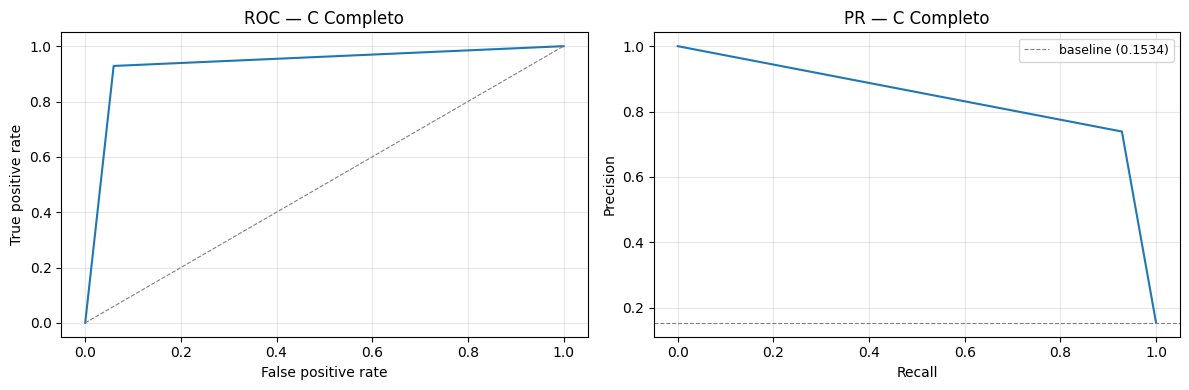

In [ ]:
FEATURES_ALL    = ["count_t","count_t1","count_t2","count_t3",
                   "nbr_t",  "nbr_t1",  "nbr_t2",  "nbr_t3",
                   "lat_idx","lon_idx","hour_sin","hour_cos"]

model_full = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    n_jobs=-1,
    random_state=42,
)
model_full.fit(df_train[FEATURES_ALL].values, y_tr,
               eval_set=[(df_val[FEATURES_ALL].values, y_va)],
               callbacks=[lgb.early_stopping(50, verbose=False)])

preds_full, roc_full, pr_full = evaluate(model_full, df_val[FEATURES_ALL].values, y_va,
                                          "C — Completo (todas las features)")
plot_curves(y_va, preds_full, "C Completo")

## Experimento D — Sin ubicación geográfica

Features: `count_t0..t3`, `nbr_t0..t3`, `hour_sin`, `hour_cos`

Mismo que el modelo completo pero sin `lat` y `lon`.

Esto responde una pregunta importante: en el experimento A vimos que
`lat_idx` y `lon_idx` tenían la mayor importancia (gain 8235 y 7842).
¿Cuánto cae el PR-AUC al quitarlos?

La diferencia entre C y D revela cuánto de la ventaja del modelo
viene de memorizar la climatología espacial de Colombia.

[LightGBM] [Info] Number of positive: 1725771, number of negative: 8353447
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.737044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1710
[LightGBM] [Info] Number of data points in the train set: 10079218, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171221 -> initscore=-1.577000
[LightGBM] [Info] Start training from score -1.577000

────────────────────────────────────────
  D — Sin ubicación (sin lat/lon)
────────────────────────────────────────
  ROC-AUC : 0.9278
  PR-AUC  : 0.7082


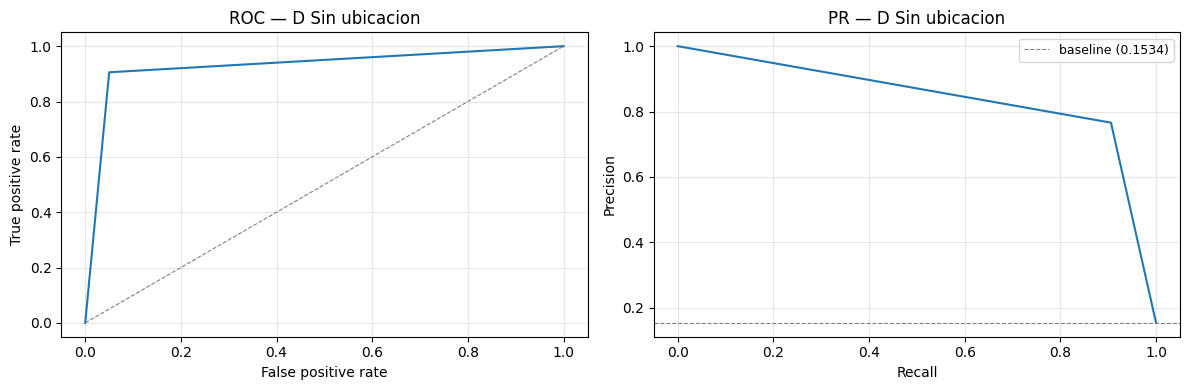

In [ ]:
FEATURES_NOPOS  = ["count_t","count_t1","count_t2","count_t3",
                   "nbr_t",  "nbr_t1",  "nbr_t2",  "nbr_t3",
                   "hour_sin","hour_cos"]

model_nopos = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    scale_pos_weight=scale,
    n_jobs=-1,
    random_state=42,
)
model_nopos.fit(df_train[FEATURES_NOPOS].values, y_tr,
                eval_set=[(df_val[FEATURES_NOPOS].values, y_va)],
                callbacks=[lgb.early_stopping(30, verbose=False)])

preds_nopos, roc_nopos, pr_nopos = evaluate(model_nopos, df_val[FEATURES_NOPOS].values, y_va,
                                             "D — Sin ubicación (sin lat/lon)")
plot_curves(y_va, preds_nopos, "D Sin ubicacion")

## Celda 9 — Tabla resumen de ablación

Comparamos los 4 experimentos en un solo lugar.

La interpretación depende de qué tan distintos sean los PR-AUC:

- **A ≈ C** → la señal predictiva viene casi toda de climatología espacial
- **B ≈ C** → la señal viene casi toda de la dinámica reciente
- **C >> A y C >> B** → ambos grupos de variables aportan de forma independiente
- **C ≈ D** → lat/lon no agregan mucho sobre lo que ya dan los conteos

El resultado de esta tabla justifica qué features vale la pena
incluir en la ConvLSTM.

In [ ]:
resultados = pd.DataFrame([
    {"Experimento": "A — Climatología",     "Features": "lat, lon, hora",       "ROC-AUC": roc_clima,  "PR-AUC": pr_clima},
    {"Experimento": "B — Dinámica pura",    "Features": "counts + vecinos",      "ROC-AUC": roc_din,    "PR-AUC": pr_din},
    {"Experimento": "D — Sin ubicación",    "Features": "counts+nbr+hora",       "ROC-AUC": roc_nopos,  "PR-AUC": pr_nopos},
    {"Experimento": "C — Completo",         "Features": "todas",                 "ROC-AUC": roc_full,   "PR-AUC": pr_full},
])

resultados["ROC-AUC"] = resultados["ROC-AUC"].map("{:.4f}".format)
resultados["PR-AUC"]  = resultados["PR-AUC"].map("{:.4f}".format)

print(resultados.to_string(index=False))

      Experimento         Features ROC-AUC PR-AUC
 A — Climatología   lat, lon, hora  0.7593 0.3758
B — Dinámica pura counts + vecinos  0.9278 0.7059
D — Sin ubicación  counts+nbr+hora  0.9278 0.7082
     C — Completo            todas  0.9345 0.6970


## Celda 10 — Importancia de variables

Visualizamos el gain de cada feature en el modelo completo.

El **gain** mide cuánto mejora cada variable la pureza de los nodos
del árbol en los que aparece — es la medida más informativa de
importancia en LightGBM.

En el experimento previo con 50 días obtuvimos:

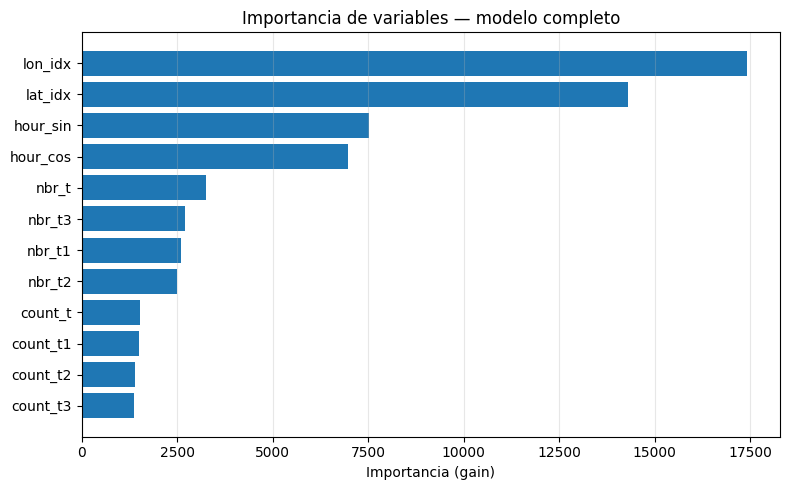

In [ ]:
feat_imp = pd.DataFrame({
    "feature":    FEATURES_ALL,
    "importance": model_full.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_imp["feature"], feat_imp["importance"])
ax.set_xlabel("Importancia (gain)")
ax.set_title("Importancia de variables — modelo completo")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lightning-prediction/plots/feature_importance.png",
            dpi=120, bbox_inches="tight")
plt.show()

## Celda 11 — Análisis de errores y elección de threshold

El modelo produce probabilidades entre 0 y 1. La elección del
**threshold** de clasificación afecta directamente el balance
entre precision y recall:

- **Threshold alto** → predicción conservadora, pocos falsos positivos,
  pero se pierden muchos rayos reales (bajo recall)
- **Threshold bajo** → predicción agresiva, alta recall,
  pero muchas falsas alarmas (baja precision)

En aplicaciones operacionales de rayos, el costo de un **falso negativo**
(no advertir un rayo que sí ocurre) suele ser mayor que el de un
**falso positivo** (alarma innecesaria). Por eso puede convenir
usar un threshold más bajo que 0.5.

La curva de esta celda permite elegir el threshold según el
caso de uso.

Threshold: 0.5

Matriz de confusión:
  TP:  353,487   FP:  124,944
  FN:   27,201   TN: 1,976,143

Precision : 0.7388
Recall    : 0.9285
F1        : 0.8229


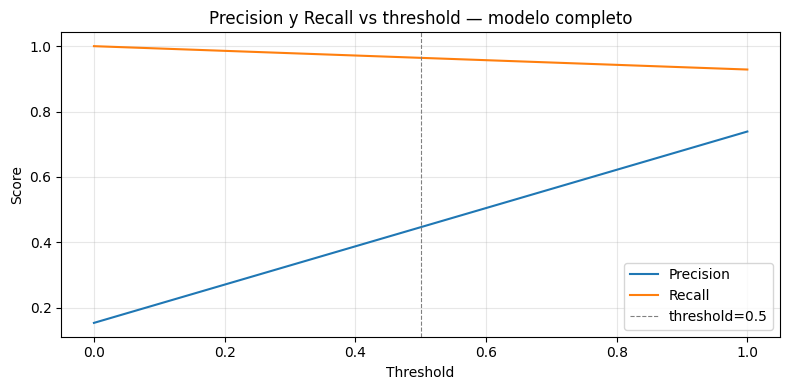

In [ ]:
# Tomamos el modelo completo y analizamos falsos positivos / negativos
threshold = 0.5

y_pred_bin = (preds_full >= threshold).astype(int)

tp = ((y_pred_bin == 1) & (y_va == 1)).sum()
fp = ((y_pred_bin == 1) & (y_va == 0)).sum()
fn = ((y_pred_bin == 0) & (y_va == 1)).sum()
tn = ((y_pred_bin == 0) & (y_va == 0)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Threshold: {threshold}")
print(f"\nMatriz de confusión:")
print(f"  TP: {tp:>8,}   FP: {fp:>8,}")
print(f"  FN: {fn:>8,}   TN: {tn:>8,}")
print(f"\nPrecision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")

# Curva de precision vs recall vs threshold
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_va, preds_full)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_arr, prec_arr[:-1], label="Precision", lw=1.5)
ax.plot(thresh_arr, rec_arr[:-1],  label="Recall",    lw=1.5)
ax.axvline(threshold, color="gray", linestyle="--", lw=0.8, label=f"threshold={threshold}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision y Recall vs threshold — modelo completo")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lightning-prediction/plots/threshold_analysis.png",
            dpi=120, bbox_inches="tight")
plt.show()

## Celda 12 — Guardar modelo

Guardamos el modelo completo en Drive con `joblib`.

El archivo `.pkl` puede cargarse después con:
```python
import joblib
model = joblib.load("lgbm_full.pkl")
preds = model.predict(X_nuevos)
```

Este modelo es el **baseline oficial** del proyecto. Cualquier
arquitectura futura (ConvLSTM, U-Net) debe superar su PR-AUC
para justificarse.

In [ ]:
import joblib

MODEL_PATH = "/content/drive/MyDrive/lightning-prediction/models/lgbm_full.pkl"
import os; os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

joblib.dump(model_full, MODEL_PATH)
print(f"Modelo guardado en: {MODEL_PATH}")

Modelo guardado en: /content/drive/MyDrive/lightning-prediction/models/lgbm_full.pkl
